In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/judo_matches.csv")

df.head()

,match_id,competition,year,weight_class,winner_throw,score,result_time
0,1,World Championship,2024,-73kg,Uchi Mata,Ippon,2:31
1,2,World Championship,2024,-81kg,Seoi Nage,Waza-ari,3:15
2,3,Olympics,2024,-66kg,O Soto Gari,Ippon,1:45
3,4,World Championship,2024,-90kg,Uchi Mata,Ippon,4:02
4,5,Olympics,2024,-73kg,Harai Goshi,Waza-ari,2:50


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   match_id      5 non-null      int64
 1   competition   5 non-null      str  
 2   year          5 non-null      int64
 3   weight_class  5 non-null      str  
 4   winner_throw  5 non-null      str  
 5   score         5 non-null      str  
 6   result_time   5 non-null      str  
dtypes: int64(2), str(5)
memory usage: 412.0 bytes


In [4]:
df["winner_throw"].value_counts()

winner_throw
Uchi Mata      2
Seoi Nage      1
O Soto Gari    1
Harai Goshi    1
Name: count, dtype: int64

# Most common throws

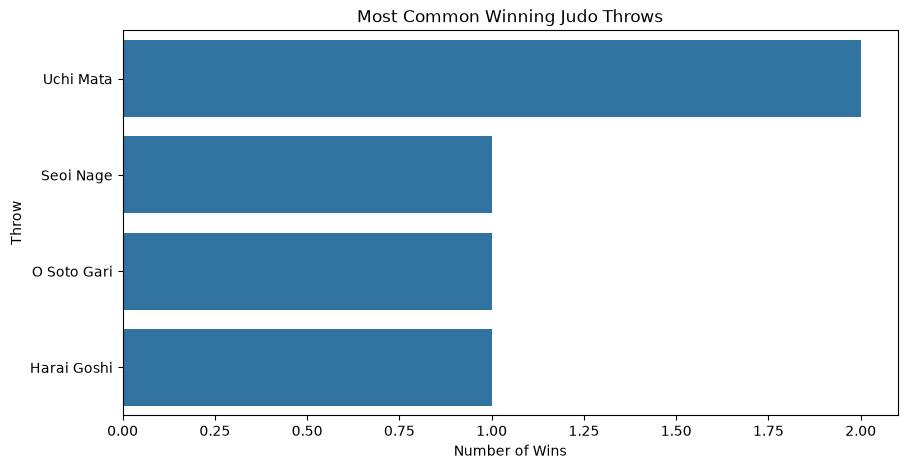

In [5]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="winner_throw",
    order=df["winner_throw"].value_counts().index
)

plt.title("Most Common Winning Judo Throws")
plt.xlabel("Number of Wins")
plt.ylabel("Throw")

plt.show()

# Calculate effectiveness

In [6]:
throw_stats = df.groupby("winner_throw").agg(
    attempts=("winner_throw","count"),
    ippon_rate=("result_time","count")
)

throw_stats

,attempts,ippon_rate
winner_throw,,
Harai Goshi,1,1
O Soto Gari,1,1
Seoi Nage,1,1
Uchi Mata,2,2
